In [11]:
from langgraph.graph import StateGraph , START,END
from typing import TypedDict
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
import plotly.express as px
import os
import json

In [12]:
load_dotenv()
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [13]:
DATABASE_NAME = "buisness_analytics"
engine = create_engine(
    "postgresql://amishiranjan@localhost:5432/buisness_analytics"
)

In [14]:
class AnalyticsState(TypedDict):
    file_path:str
    df: pd.DataFrame
    data_report:dict
    
    database_name: str
    table_name: str
    upload_status: str

    generated_queries: str

    query_results: dict


In [15]:
def load_file(state:AnalyticsState) -> AnalyticsState:
    
    file_path = state["file_path"]
    if file_path.endswith(".csv"):
        df = pd.read_csv(file_path)
    elif file_path.endswith(".json"):
        df = pd.read_json(file_path)
    else:
        raise ValueError("Unsupported file format")
    
    
    state["df"] = df
    return state


In [16]:
def data_clean(state:AnalyticsState) -> AnalyticsState:
    df = state["df"]
    report={
        "rows": len(df),
        "columns": len(df.columns),
        "missing_values": df.isnull().sum().to_dict(),
        "total_missing": int(df.isnull().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum())
    }
    state["data_report"] = report
    return state


In [17]:
def upload_to_db(state:AnalyticsState) -> AnalyticsState:
    DATABASE_NAME = "buisness_analytics"
    df = state["df"]
    # sales.csv -> sales
    filename = os.path.basename(state["file_path"])

    table_name = (
        os.path.splitext(filename)[0]
        .lower()
        .replace(" ", "_")
    )

    df.to_sql(
        table_name,
        con=engine,
        if_exists="replace",
        index=False
    )

    state["database_name"] = DATABASE_NAME
    state["table_name"] = table_name

    state["upload_status"] = (
        f"{len(df)} rows uploaded to "
        f"{DATABASE_NAME}.{table_name}"
    )

    return state

In [18]:
def llm_layer(state:AnalyticsState) -> AnalyticsState:
    df = state["df"]

    prompt = f"""
    You are an expert business analyst.
    Dataset Schema:
    {df.dtypes.astype(str).to_dict()}
    
    Sample Data:
    {df.head(10).to_dict(orient="records")}
    Analyze the dataset and determine the most valuable insights that can be extracted.

    Generate the TOP 5 SQL queries that would provide the highest analytical value.

    Requirements:
    - Do not assume any industry or business domain.
    - Use only available columns.
    - Each query should answer a different analytical question.
    - Prefer meaningful aggregations, trends, rankings, comparisons,
      correlations, segmentations, or anomaly detection.
    - Assume the SQLite table name is 'data'.
    - Return ONLY valid JSON.

    Necessary:
    All column names must be wrapped in double quotes exactly as shown in the schema.

    For each SQL query also recommend the best visualization.

Allowed chart types:
- bar
- horizontal_bar
- line
- pie
- scatter
- table

Rules:
- Rankings → horizontal_bar
- Category comparisons → bar
- Percentages/shares → pie
- Time trends → line
- Numeric relationships → scatter
- Detailed records → table

Target database: PostgreSQL.

Rules:
1. Use NUMERIC instead of REAL when ROUND(value, decimals) is required.
2. Never generate ROUND(double precision, integer).
3. Use COUNT(*)::NUMERIC and SUM(...)::NUMERIC for percentage calculations.
4. Generate PostgreSQL-compatible SQL only.



    Required Output Format:

[
  {{
    "title": "Insight Name",
    "query": "SELECT ..."
    "chart_type": "horizontal_bar"
  }},
  {{
    "title": "Insight Name",
    "query": "SELECT ..."
    "chart_type": "pie"
  }}
]
"""
    response = model.invoke(prompt)

    state["generated_queries"] = response.content

    return {
        "generated_queries": response.content
    }


In [19]:
import json

def execute_query(state: AnalyticsState) -> AnalyticsState:
    try:
        cleaned = state["generated_queries"]
        cleaned = cleaned.replace("```json", "")
        cleaned = cleaned.replace("```", "")
        cleaned = cleaned.strip()
        queries = json.loads(cleaned)
    except (json.JSONDecodeError, TypeError) as e:
        print(f"Error parsing generated queries: {e}")

        return {
            "query_results": {}
        }

    results = {}

    for q in queries:
        title = q["title"]
        sql = q["query"]

        sql = sql.replace("data", state["table_name"])

        try:
            result_df = pd.read_sql(sql, engine)

            results[title] = result_df

            print(f"\n=== {title} ===")
            print(result_df.head(10))

        except Exception as e:
            print(f"Error in {title}: {e}")

    return {
        "query_results": results
    }

In [20]:
import subprocess


def plot_result(state: AnalyticsState) -> AnalyticsState:

   
    print("PLOT NODE REACHED")

    query_results = state.get("query_results", {})
    generated_queries = state.get("generated_queries", "")

    figures = []

    try:
        cleaned = (
            generated_queries
            .replace("```json", "")
            .replace("```", "")
            .strip()
        )

        queries = json.loads(cleaned)

    except Exception as e:
        print("JSON ERROR:", e)
        return state

    print("\nQueries Found:\n")
    print(queries)

    for q in queries:

        title = q.get("title", "Untitled Chart")
        chart_type = q.get("chart_type", "table")

        print(f"\nTITLE: {title}")
        print(f"CHART TYPE: {chart_type}")

        result_df = query_results.get(title)

        if result_df is None:
            print("DataFrame NOT FOUND")
            continue

        print("Rows:", len(result_df))
        print("Columns:", list(result_df.columns))

        if len(result_df.columns) < 2:
            print("Not enough columns to plot")
            continue

        try:

            if chart_type == "pie":

                if len(result_df) > 100:
                    print(f"Skipping pie chart '{title}' ({len(result_df)} slices)")
                    continue

                fig = px.pie(
                    result_df,
                    names=result_df.columns[0],
                    values=result_df.columns[1],
                    title=title
                )

            elif chart_type == "horizontal_bar":

                fig = px.bar(
                    result_df,
                    x=result_df.columns[1],
                    y=result_df.columns[0],
                    orientation="h",
                    title=title
                )

            elif chart_type == "bar":

                fig = px.bar(
                    result_df,
                    x=result_df.columns[0],
                    y=result_df.columns[1],
                    title=title
                )

            elif chart_type == "table":

                print("\nTABLE OUTPUT:")
                print(result_df.to_string(index=False))
                continue

            else:

                fig = px.bar(
                    result_df,
                    x=result_df.columns[0],
                    y=result_df.columns[1],
                    title=title
                )

            figures.append(fig)

        except Exception as e:
            print("PLOT ERROR:", e)

    if figures:

        html_content = """
        <html>
        <head>
            <title>Analytics Dashboard</title>
        </head>
        <body>
            <h1>Analytics Dashboard</h1>
        """

        first = True

        for fig in figures:
            html_content += fig.to_html(
                full_html=False,
                include_plotlyjs="cdn" if first else False
            )
            first = False

        html_content += """
        </body>
        </html>
        """

        dashboard_file = os.path.abspath("dashboard.html")

        with open(dashboard_file, "w", encoding="utf-8") as f:
            f.write(html_content)

        print("\nDashboard saved at:")
        print(dashboard_file)

        subprocess.run(["open", dashboard_file])

    return state

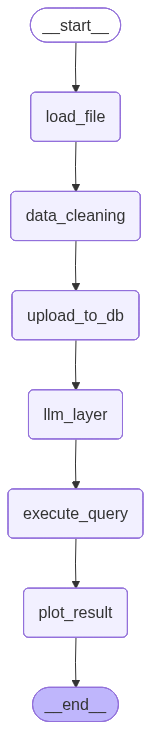

In [21]:
graph = StateGraph(AnalyticsState)

# Nodes
graph.add_node("load_file", load_file)
graph.add_node("data_cleaning", data_clean)
graph.add_node("upload_to_db", upload_to_db)
graph.add_node("llm_layer", llm_layer)
graph.add_node("execute_query", execute_query)  
graph.add_node("plot_result", plot_result)

# Edges
graph.add_edge(START, "load_file")
graph.add_edge("load_file", "data_cleaning")
graph.add_edge("data_cleaning", "upload_to_db")
graph.add_edge("upload_to_db", "llm_layer")
graph.add_edge("llm_layer", "execute_query")
graph.add_edge("execute_query", "plot_result")
graph.add_edge("plot_result", END)

graph.compile()

In [ ]:
workflow=graph.compile()
initial_state={"file_path":"retail_sales_dataset.csv"}
final_state=workflow.invoke(initial_state)
print(final_state["data_report"])
print(final_state["generated_queries"])
final_state["query_results"]

FileNotFoundError: [Errno 2] No such file or directory: '.csv'